# Recorrência temporal: taxa de reciclagem 

**Pergunta de produto:** alegações falsas voltam a circular depois de checadas? Se sim, um sistema que *recupera a checagem antiga* quando a alegação reaparece tem valor. Se quase nada volta, o produto precisa de outro enquadramento.


In [52]:
%pip install -q pandas numpy matplotlib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [53]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)
SEED = 42

## 1. Carregar e alinhar

As fontes precisam estar **alinhadas linha a linha**: o CSV, a matriz de embeddings (linha *k* = vetor da alegação *k*) e os clusters do 02. Se desalinhar, todo número depois fica errado sem dar erro. Por isso guardamos `idx` (a linha original no `com_texto_limpo.csv`) e fazemos `assert`.

Saem do corpus:
- **multi-alegação** ("Veja o que é #FATO ou #FAKE…"): não são uma alegação só.
- **sem data** (`NaT`): sem data não existe "antes/depois".

In [54]:
df = pd.read_csv("data/com_texto_limpo.csv")
embeddings = np.load("data/emb_minilm.npy")
assert len(df) == len(embeddings)

df["data"] = pd.to_datetime(df["Data da checagem"])
df["idx"] = np.arange(len(df))

manter = (~df["multi_claim"] & df["data"].notna()).to_numpy()
df = df[manter].reset_index(drop=True)
E = embeddings[manter]

clusters = pd.read_csv("data/clusters.csv")[["idx", "cluster_hdbscan"]]
df = df.merge(clusters, on="idx", how="left", validate="one_to_one")
assert len(df) == len(E)

print(f"Alegações: {len(df)} | período: {df['data'].min().date()} a {df['data'].max().date()} "
      f"({(df['data'].max() - df['data'].min()).days} dias)")

Alegações: 1844 | período: 2022-08-01 a 2022-12-01 (122 dias)


## 2. A matriz de similaridade S

Os embeddings foram gerados com `normalize_embeddings=True`: todo vetor tem norma 1. Com norma 1, o cosseno entre *a* e *b* é só o produto escalar `a · b`. Então `E @ E.T` calcula **todas** as similaridades de uma vez: `S[i, j] = cos(i, j)`.


In [55]:
S = E @ E.T
print("shape:", S.shape, "| memória:", round(S.nbytes / 1e6, 1), "MB")
print("diagonal ≈ 1?", np.allclose(np.diag(S), 1, atol=1e-4))
print("simétrica?", np.allclose(S, S.T, atol=1e-6))

# A diagonal é a alegação com ela mesma: tiramos do jogo, senão todo mundo é "gêmeo" de si
np.fill_diagonal(S, -1)

shape: (1844, 1844) | memória: 13.6 MB
diagonal ≈ 1? True
simétrica? True


Uma linha de S é "a alegação *i* contra o corpus inteiro". Ordenar essa linha **é** a busca semântica que o produto vai fazer.

In [56]:
def vizinhos(i, k=5):
    print(f"ALVO [{i}] ({df.at[i, 'data'].date()}, {df.at[i, 'Agência']}): {df.at[i, 'claim']}")
    for j in np.argsort(-S[i])[:k]:
        print(f"  {S[i, j]:.3f} | {df.at[j, 'data'].date()} | {df.at[j, 'Agência']:<20.20} | {df.at[j, 'claim'][:90]}")

vizinhos(df.index[df["claim"].str.contains("agronegócio", na=False)][0])

ALVO [7] (2022-08-05, AFP Checamos): Lula disse que o agronegócio deve ser "eliminado da Terra"
  0.994 | 2022-08-05 | Aos Fatos            | Lula disse que agronegócio deve ser ‘eliminado da Terra’
  0.984 | 2022-08-04 | Boatos.org           | Lula diz que agronegócio deve ser eliminado da Terra
  0.932 | 2022-08-05 | Agência Lupa         | Lula e MST disseram que o agronegócio deve ser eliminado da Terra
  0.630 | 2022-10-30 | Boatos.org           | Lula diz que quer acabar com o MEI (regime de Microempreendedor Individual)
  0.609 | 2022-08-10 | Projeto Comprova     | Não há registro público de declaração de Lula nem do MST sobre eliminar agronegócio da Ter


## 3. Calibrar a intuição sobre τ

τ é o limiar: acima dele, "é a mesma alegação". 

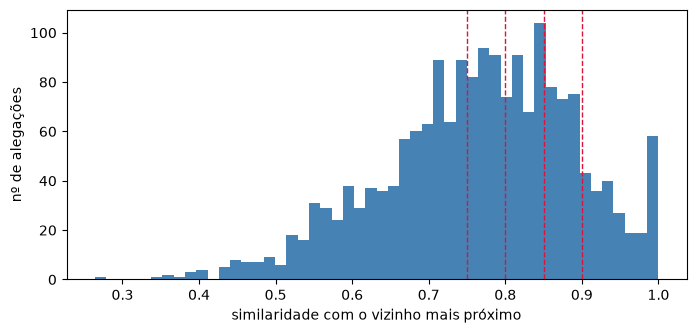

vizinho ≥ 0.75: 58.1%
vizinho ≥ 0.80: 41.5%
vizinho ≥ 0.85: 26.1%
vizinho ≥ 0.90: 12.5%
vizinho ≥ 0.95: 5.5%


In [57]:
nn = S.max(axis=1)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(nn, bins=50, color="steelblue")
for t in [0.75, 0.80, 0.85, 0.90]:
    ax.axvline(t, color="crimson", ls="--", lw=1)
ax.set_xlabel("similaridade com o vizinho mais próximo"); ax.set_ylabel("nº de alegações")
plt.show()
for t in [0.75, 0.80, 0.85, 0.90, 0.95]:
    print(f"vizinho ≥ {t:.2f}: {(nn >= t).mean():.1%}")

In [58]:
rng = np.random.default_rng(SEED)
iu, ju = np.triu_indices(len(df), k=1) 
s_pares = S[iu, ju]

for lo, hi in [(0.70, 0.75), (0.75, 0.80), (0.80, 0.85), (0.85, 0.90), (0.90, 0.95), (0.95, 1.01)]:
    na_faixa = np.flatnonzero((s_pares >= lo) & (s_pares < hi))
    print(f"\n=== faixa [{lo:.2f}, {hi:.2f}): {len(na_faixa)} pares ===")
    for k in rng.choice(na_faixa, size=min(4, len(na_faixa)), replace=False):
        i, j = iu[k], ju[k]
        print(f"  {s_pares[k]:.2f} | {df.at[i, 'claim'][:70]}\n       | {df.at[j, 'claim'][:70]}")


=== faixa [0.70, 0.75): 2932 pares ===
  0.73 | 5,1 milhões de votos foram 'roubados' de Bolsonaro
       | Seção sem voto para Bolsonaro no MT comprova fraude eleitoral
  0.74 | Declaração de Ciro Gomes sobre "fraude eleitoral" não era sobre segura
       | Sugerir fraude nas urnas no interior de SP
  0.75 | Relatório das Forças Armadas descobriu fraude nas urnas eletrônicas?
       | Relatório apócrifo comprova fraude nas eleições
  0.71 | Eleições presidenciais não foram invalidadas por fraudes em 234 seções
       | Lista com seções sem votos em Bolsonaro não comprova fraude eleitoral

=== faixa [0.75, 0.80): 1120 pares ===
  0.80 | Áudio viral mente sobre suposto controle de votos por parte de grupo s
       | Áudio inventa grupo secreto do PT e mente sobre controle de votos
  0.78 | Vídeo mostra simulação de fraude em urna diferente da usada no Brasil
       | Auditoria na Argentina comprova fraude nas urnas brasileiras e é apres
  0.77 | A Jovem Pan News mostrou Bolsonaro com 5

## 4. A dimensão tempo

`data_i − data_j` para **todos** os pares. Em vez de dois `for`, usamos *broadcasting*: `a[:, None]` vira uma coluna (n×1), `a[None, :]` vira uma linha (1×n), e a subtração gera a matriz n×n.

**Decisão de definição (importante):** usamos a diferença **com sinal**, `delta[i, j] = data_i − data_j`. `delta ≥ N` significa "*j* foi checada pelo menos N dias **antes** de *i*". Então *i* é a **reciclagem** e *j* é o original.


In [59]:
datas = df["data"].to_numpy()
delta = (datas[:, None] - datas[None, :]) / np.timedelta64(1, "D")  # em dias, com sinal
print("delta[0, :5] =", delta[0, :5])

delta[0, :5] = [ 0.  0. -1. -2. -2.]


## 5. Filtros

Nem todo par "similar e distante no tempo" é reciclagem. Há duas armadilhas conhecidas:

1. **Agregador:** o *Fato ou Boato* (Justiça Eleitoral) republica checagens de parceiros, dias depois. O par (checagem original, republicação) parece reciclagem, mas é a mesma checagem copiada. Tiramos todo par que envolva o agregador.
2. **Duplicata:** textos quase idênticos (`cos > 0,98`) da **mesma agência** tendem a ser a mesma matéria atualizada ou republicada, e não a alegação voltando. As duplicatas exatas de coleta já saíram no 00.

A função abaixo junta tudo. Tudo são matrizes booleanas n×n combinadas com `&` (e) e `~` (não).

In [60]:
agencia = df["Agência"].to_numpy(dtype=object)  # pandas 3: .to_numpy() evita comparações estranhas com o tipo string
agregador = df["agregador"].to_numpy(dtype=bool)

mesma_agencia = agencia[:, None] == agencia[None, :]
envolve_agregador = agregador[:, None] | agregador[None, :]

def pares_reciclagem(tau, N, tirar_agregador=True, tirar_duplicata=True):
    """Matriz booleana: P[i, j] = True se j é um 'original' de i (similar e ≥ N dias antes)."""
    P = (S >= tau) & (delta >= N)
    if tirar_agregador:
        P &= ~envolve_agregador
    if tirar_duplicata:
        P &= ~((S > 0.98) & mesma_agencia)
    return P

def taxa_reciclagem(tau, N, **filtros):
    # .any(axis=1): a linha i tem PELO MENOS UM original?
    return pares_reciclagem(tau, N, **filtros).any(axis=1).mean()

In [61]:
tau_ex = 0.85
funil = {
    "similar (S ≥ τ), qualquer data":        ((S >= tau_ex) & (delta >= 0)).sum(),
    "+ j pelo menos 7 dias antes":           pares_reciclagem(tau_ex, 7, tirar_agregador=False, tirar_duplicata=False).sum(),
    "+ sem agregador":                       pares_reciclagem(tau_ex, 7, tirar_duplicata=False).sum(),
    "+ sem duplicata da mesma agência":      pares_reciclagem(tau_ex, 7).sum(),
}
pd.Series(funil, name="nº de pares")

similar (S ≥ τ), qualquer data      471
+ j pelo menos 7 dias antes         113
+ sem agregador                      93
+ sem duplicata da mesma agência     90
Name: nº de pares, dtype: int64

## 7. A grade τ × N


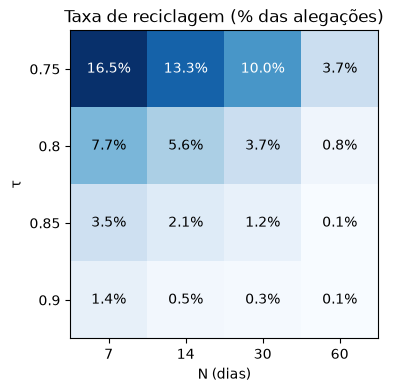

In [62]:
TAUS = [0.75, 0.80, 0.85, 0.90]
NS = [7, 14, 30, 60]

grade = pd.DataFrame([[taxa_reciclagem(t, n) for n in NS] for t in TAUS],
                     index=pd.Index(TAUS, name="τ"), columns=pd.Index(NS, name="N (dias)"))
grade.to_csv(RESULTS / "taxa_reciclagem_grade.csv")

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(grade.values * 100, cmap="Blues")
ax.set_xticks(range(len(NS)), NS); ax.set_yticks(range(len(TAUS)), TAUS)
ax.set_xlabel("N (dias)"); ax.set_ylabel("τ")
for a in range(len(TAUS)):
    for b in range(len(NS)):
        ax.text(b, a, f"{grade.values[a, b]:.1%}", ha="center", va="center",
                color="white" if grade.values[a, b] > grade.values.max() / 2 else "black")
ax.set_title("Taxa de reciclagem (% das alegações)")
fig.savefig(RESULTS / "taxa_reciclagem_grade.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Validação manual:

A precisão responde: dos pares que o detector aponta, que fração é realmente a mesma alegação?

In [63]:
N_VAL = 7
FAIXAS = [(0.75, 0.80), (0.80, 0.85), (0.85, 0.90), (0.90, 1.01)]
POR_FAIXA = 8

caminho_val = RESULTS / "validacao_pares.csv"
if not caminho_val.exists():
    P = pares_reciclagem(0.75, N_VAL)
    ii, jj = np.nonzero(P)
    sims = S[ii, jj]
    linhas = []
    for lo, hi in FAIXAS:
        na_faixa = np.flatnonzero((sims >= lo) & (sims < hi))
        for k in rng.choice(na_faixa, size=min(POR_FAIXA, len(na_faixa)), replace=False):
            i, j = ii[k], jj[k]
            linhas.append({"faixa": f"{lo:.2f}-{min(hi, 1):.2f}", "sim": round(float(sims[k]), 3),
                           "dias": int(delta[i, j]), "idx_i": df.at[i, "idx"], "idx_j": df.at[j, "idx"],
                           "reciclada_i": df.at[i, "claim"], "original_j": df.at[j, "claim"], "rotulo": ""})
    pd.DataFrame(linhas).to_csv(caminho_val, index=False)
    print(f"Criado {caminho_val} com {len(linhas)} pares: preencha a coluna 'rotulo'.")


validacao = pd.read_csv(caminho_val, dtype={"rotulo": str})
validacao["rotulo"] = validacao["rotulo"].fillna("").str.strip().str.lower()
validacao[["faixa", "sim", "dias", "reciclada_i", "original_j", "rotulo"]]

,faixa,sim,dias,reciclada_i,original_j,rotulo
0,0.75-0.80,0.780,60,Lula usou ponto eletrônico em debate da Globo,Globo entregou folha com respostas a Lula no J...,tema
1,0.75-0.80,0.797,92,Janones não disse que Lula vai acabar com Auxí...,"Ao contrário do que afirma vídeo, Lula não dis...",diferente
2,0.75-0.80,0.786,17,Vídeo que mostra Lula supostamente xingando ap...,É falsa foto de Silas Malafaia apoiando Lula e...,tema
3,0.75-0.80,0.780,30,Vídeo mente ao insinuar que protesto em Recife...,Comício de Lula em Curitiba não estava vazio; ...,tema
4,0.75-0.80,0.763,7,Felipão declarou apoio a Lula,Padre Marcelo Rossi manifestou apoio à candida...,tema
...,...,...,...,...,...,...
66,0.85-0.90,0.891,24,Alexandre de Moraes vendeu as eleições de 2022...,Alexandre de Moraes vendeu as eleições 2022 pa...,mesma
67,0.85-0.90,0.881,53,Vídeos mostram protestos antigos no Chile e no...,"Vídeo mostra dispersão de protesto, não saques...",tema
68,0.85-0.90,0.873,48,Associar retirada de urnas de prédio a fraude ...,Sugerir fraude nas urnas no interior de SP,tema
69,0.85-0.90,0.856,7,Site esportivo da Globo não publicou que Lula ...,Ge publicou reportagem afirmando que Lula prom...,tema


### Ampliar a amostra

Com n = 8 por faixa, o IC 95% da precisão fica em ±30 p.p. (ex.: 5/8 → 31–86%), largo demais para comparar com a régua do critério. Completamos **só as faixas 0,80–0,85 e 0,85–0,90** até **30 pares cada**, o que deixa o IC em ~±15 p.p.

In [64]:
import shutil

FAIXAS_EXTRA = [(0.80, 0.85), (0.85, 0.90)]
META_POR_FAIXA = 30
rng_extra = np.random.default_rng(SEED + 1)  # outra seed: não reproduz o sorteio original

# 1)  Linhas JÁ ROTULADAS ficam sempre; as não rotuladas que repetem alegação saem.
chave = lambda s: str(s).strip().lower()
usadas, manter = set(), []
for _, r in validacao.iterrows():
    a, b = chave(r["reciclada_i"]), chave(r["original_j"])
    ok = r["rotulo"] != "" or (a not in usadas and b not in usadas)
    manter.append(ok)
    if ok:
        usadas |= {a, b}
removidas = len(validacao) - sum(manter)
validacao = validacao[manter].reset_index(drop=True)

# 2) Completa as faixas até META_POR_FAIXA, respeitando a mesma regra
P = pares_reciclagem(0.75, N_VAL)
ii, jj = np.nonzero(P)
sims = S[ii, jj]

linhas = []
for lo, hi in FAIXAS_EXTRA:
    nome = f"{lo:.2f}-{hi:.2f}"
    faltam = META_POR_FAIXA - (validacao["faixa"] == nome).sum()
    candidatos = rng_extra.permutation(np.flatnonzero((sims >= lo) & (sims < hi)))
    adicionados = 0
    for k in candidatos:
        if adicionados >= faltam:
            break
        i, j = ii[k], jj[k]
        a, b = chave(df.at[i, "claim"]), chave(df.at[j, "claim"])
        if a in usadas or b in usadas:
            continue
        usadas |= {a, b}
        adicionados += 1
        linhas.append({"faixa": nome, "sim": round(float(sims[k]), 3),
                       "dias": int(delta[i, j]), "idx_i": df.at[i, "idx"], "idx_j": df.at[j, "idx"],
                       "reciclada_i": df.at[i, "claim"], "original_j": df.at[j, "claim"], "rotulo": ""})
    print(f"{nome}: faltavam {max(faltam, 0)}, adicionados {adicionados}")

if linhas or removidas:
    shutil.copy(caminho_val, caminho_val.with_name("validacao_pares_backup.csv"))
    validacao = pd.concat([validacao, pd.DataFrame(linhas)], ignore_index=True)
    assert not validacao.duplicated(["idx_i", "idx_j"]).any(), "par repetido no CSV!"
    validacao.to_csv(caminho_val, index=False)
    print(f"\n-{removidas} não rotulados com alegação repetida | +{len(linhas)} novos -> {caminho_val}")

validacao.groupby("faixa")["rotulo"].agg(n="size", rotulados=lambda r: (r != "").sum())

0.80-0.85: faltavam 0, adicionados 0
0.85-0.90: faltavam 5, adicionados 0


,n,rotulados
faixa,,
0.75-0.80,8,8
0.80-0.85,30,30
0.85-0.90,25,25
0.90-1.00,8,8


### Precisão por faixa → escolha do τ

In [65]:
def wilson(k, n, z=1.96):
    """IC 95% de Wilson para a proporção k/n (mais confiável que o intervalo normal com n pequeno ou p perto de 0/1)."""
    p = k / n
    d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return c - h, c + h

rotulados = validacao[validacao["rotulo"].isin(["mesma", "tema", "diferente"])]
if len(rotulados) < len(validacao):
    print(f"⚠️ {len(validacao) - len(rotulados)} pares sem rótulo: preencha antes de escolher o τ.")

if len(rotulados):
    tipo = rotulados["tipo"] if "tipo" in rotulados else pd.Series("", index=rotulados.index)
    rotulados = rotulados.assign(acerto=rotulados["rotulo"].eq("mesma"),
                                 tipo=tipo.fillna("").astype(str).str.strip().str.lower())
    linhas = []
    for faixa, g in rotulados.groupby("faixa"):
        acum = rotulados[rotulados["sim"] >= float(faixa.split("-")[0])]
        k, n, ka, na = g["acerto"].sum(), len(g), acum["acerto"].sum(), len(acum)
        linhas.append({"faixa": faixa, "n": n, "precisao": k / n, "ic95": "[{:.0%}, {:.0%}]".format(*wilson(k, n)),
                       "n_acum (≥ faixa)": na, "precisao_acumulada (≥ faixa)": ka / na,
                       "ic95_acum": "[{:.0%}, {:.0%}]".format(*wilson(ka, na))})
    por_faixa = pd.DataFrame(linhas).set_index("faixa")
    por_faixa.to_csv(RESULTS / "precisao_por_faixa.csv")
    display(por_faixa.round(2))

    # Como a reescrita aconteceu × se é a mesma alegação. Muito 'repetida' = os filtros de agregador/duplicata vazaram
    display(pd.crosstab(rotulados["tipo"].replace("", "(vazio)"), rotulados["rotulo"], margins=True))

,n,precisao,ic95,n_acum (≥ faixa),precisao_acumulada (≥ faixa),ic95_acum
faixa,,,,,,
0.75-0.80,8,0.12,"[2%, 47%]",71,0.48,"[37%, 59%]"
0.80-0.85,30,0.30,"[17%, 48%]",63,0.52,"[40%, 64%]"
0.85-0.90,25,0.68,"[48%, 83%]",33,0.73,"[56%, 85%]"
0.90-1.00,8,0.88,"[53%, 98%]",8,0.88,"[53%, 98%]"


rotulo,diferente,mesma,tema,All
tipo,,,,
(vazio),9,6,28,43
detalhe,0,8,0,8
negacao,0,7,0,7
parafrase,0,13,0,13
All,9,34,28,71


In [66]:
TAU = 0.75   
N = 7        
print(f"Taxa de reciclagem com τ={TAU}, N={N}: {taxa_reciclagem(TAU, N):.1%}")

Taxa de reciclagem com τ=0.75, N=7: 16.5%


## 9. Quais temas reciclam mais?


In [67]:
df["reciclada"] = pares_reciclagem(TAU, N).any(axis=1)

por_cluster = (df[df["cluster_hdbscan"] >= 0]
               .groupby("cluster_hdbscan")
               .agg(tamanho=("reciclada", "size"), taxa=("reciclada", "mean"),
                    exemplo=("claim", "first"))
               .query("tamanho >= 15")
               .sort_values("taxa", ascending=False))
por_cluster.to_csv(RESULTS / "reciclagem_por_cluster.csv")
por_cluster.head(10).style.format({"taxa": "{:.1%}"})

,tamanho,taxa,exemplo
cluster_hdbscan,,,
15,67,61.2%,Vídeo de 2020 é usado para sugerir que Ratinho agendou entrevista com Bolsonaro em 25/08/2022
11,94,29.8%,"Número divulgado por usuários em referência a Bolsonaro é de 2018; em 2022, ele usa 22"
23,38,28.9%,"Vídeo que pede que eleitores fotografem boletins de urna é de 2014, ação não está vigente em 2022"
6,466,20.8%,O portal g1 não noticiou que banqueiros apoiarão Lula em troca de revogação do PIX
14,135,20.0%,Vídeo de Tom Cruise segurando um emblema escrito “Brasil” não era em apoio a Bolsonaro
20,28,17.9%,Comparação entre gráficos de apuração no Brasil e nos EUA não prova fraude; sistemas são distintos
22,69,17.4%,Denúncia de policiais sobre suposto problema nas urnas é de 2018 e foi considerada infundada
4,21,14.3%,"Os homens com tatuagens nazistas fotografados em uma praia são húngaros, não refugiados ucranianos"
13,16,12.5%,"Mulher que diz em vídeo que sistema eleitoral brasileiro é ""inauditável"" não é funcionária do TSE"


## 10. Guardar os pares para o conjunto de teste

In [68]:
if len(rotulados):
    temporais = rotulados[rotulados["acerto"]][["idx_i", "idx_j", "sim", "dias", "reciclada_i", "original_j"]]
    temporais.to_csv("data/pares_temporais.csv", index=False)
    print(f"{len(temporais)} pares temporais salvos em data/pares_temporais.csv")

34 pares temporais salvos em data/pares_temporais.csv
